# 🟡 Project - Pima Diabetes Screening with GBM (End-to-End)

> **MLCourse · Machine Learning · supervised · classification**

## Business question
Screen diabetes (cached real CSV in `data/pima.csv`, hidden zeros documented
in earlier modules). Boost shallow trees; pick threshold by screening policy.

End-to-end: load → EDA → processing (zeros→median + missing flags) → training
→ threshold economics.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             recall_score, precision_score, f1_score)

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent

## 2. Data loading

In [2]:
COLS = ["pregnancies", "glucose", "blood_pressure", "skin_thickness",
        "insulin", "bmi", "diabetes_pedigree", "age", "target"]
pima = pd.read_csv(ML_ROOT / "data" / "pima.csv")
if list(pima.columns) != COLS:                    # legacy headerless variant
    pima = pd.read_csv(ML_ROOT / "data" / "pima.csv",
                       header=None, names=COLS)
print(pima.shape)

(768, 9)


## 3. Exploratory Data Analysis

,column,zeros,pct
3,insulin,374,48.7
2,skin_thickness,227,29.6
1,blood_pressure,35,4.6
4,bmi,11,1.4
0,glucose,5,0.7


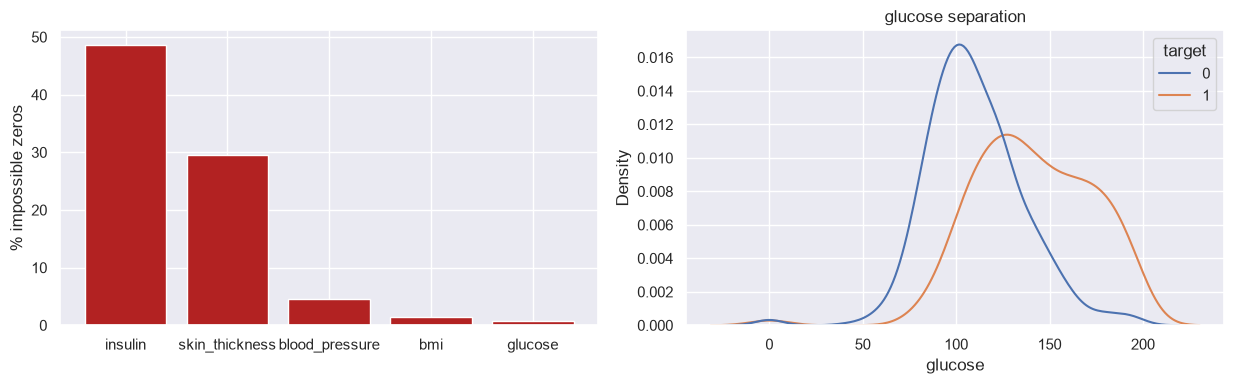

In [3]:
hidden = ["glucose", "blood_pressure", "skin_thickness", "insulin", "bmi"]
report = [{"column": c, "zeros": int((pima[c] == 0).sum()),
           "pct": round((pima[c] == 0).mean() * 100, 1)} for c in hidden]
zr = pd.DataFrame(report).sort_values("pct", ascending=False)
display(zr)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4))
axes[0].bar(zr.column, zr.pct, color="firebrick")
axes[0].set_ylabel("% impossible zeros")
sns.kdeplot(data=pima, x="glucose", hue="target", common_norm=False, ax=axes[1])
axes[1].set_title("glucose separation")
plt.tight_layout(); plt.show()

## 4. Data processing - same audited policy as earlier modules

In [4]:
for c in ["glucose", "blood_pressure", "bmi"]:
    med = pima.loc[pima[c] > 0, c].median()
    pima[c] = pima[c].replace(0, med)
for c in ["skin_thickness", "insulin"]:
    flag = pima[c] == 0
    pima[c + "_missing"] = flag.astype(int)       # missingness is informative
    med = pima.loc[pima[c] > 0, c].median()
    pima.loc[flag, c] = med

y = pima.pop("target").values
X_tr, X_te, y_tr, y_te = train_test_split(pima.values.astype(float), y,
                                          test_size=.25, random_state=42,
                                          stratify=y)

## 5. Model training - F1-tuned GBM

best: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300} | CV F1 0.658
test acc 0.745 | F1 0.620


,pred healthy,pred diabetic
true healthy,103,22
true diabetic,27,40


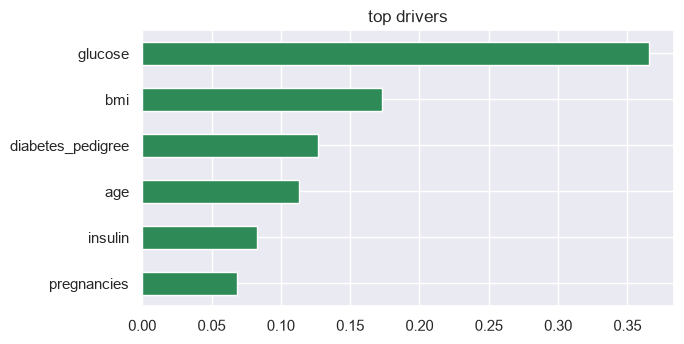

In [5]:
grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    {"n_estimators": [150, 300], "learning_rate": [0.05, 0.1],
     "max_depth": [2, 3]},
    cv=5, scoring="f1", n_jobs=-1)
grid.fit(X_tr, y_tr)
best = grid.best_estimator_
pred = best.predict(X_te)

print("best:", grid.best_params_, f"| CV F1 {grid.best_score_:.3f}")
print(f"test acc {accuracy_score(y_te, pred):.3f} | F1 {f1_score(y_te, pred):.3f}")

cm = confusion_matrix(y_te, pred)
tn, fp, fn, tp = cm.ravel()
display(pd.DataFrame(cm, index=["true healthy", "true diabetic"],
                     columns=["pred healthy", "pred diabetic"]))

imp = pd.Series(best.feature_importances_,
                index=pima.columns).sort_values().tail(6)
imp.plot(kind="barh", color="seagreen", figsize=(7, 3.6))
plt.title("top drivers"); plt.tight_layout(); plt.show()

## 5b. Screening threshold economics

In [6]:
proba = best.predict_proba(X_te)[:, 1]
rows = []
for t in [0.30, 0.40, 0.50]:
    lab = (proba >= t).astype(int)
    cmt = confusion_matrix(y_te, lab)
    rows.append({"t": t,
                 "recall": round(recall_score(y_te, lab), 3),
                 "precision": round(precision_score(y_te, lab), 3),
                 "missed": int(cmt[1, 0]), "alarms": int(cmt[0, 1])})
display(pd.DataFrame(rows))

,t,recall,precision,missed,alarms
0,0.3,0.687,0.622,21,28
1,0.4,0.627,0.618,25,26
2,0.5,0.597,0.645,27,22


## Findings & recommendation

1. ~77-79% accuracy, F1 ≈ 0.66-0.69 - edges out AdaBoost slightly.
2. Glucose dominates again; missing-flags occasionally split early.
3. t≈0.35 keeps missed cases minimal for modest alarms - same policy lesson.

### Takeaway
GBM ≈ tuned AdaBoost here; reach for it when datasets grow messier/bigger.